# Task 1 – Intersection over Union (IoU)

In [2]:
def compute_iou(box1, box2):
    """
    Computes Intersection over Union (IoU) between two bounding boxes.

    Parameters:
        box1, box2: list or tuple of format [x_min, y_min, x_max, y_max]

    Returns:
        float: IoU score
    """

    # Intersection coordinates
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Compute intersection area
    inter_width = max(0, x_right - x_left)
    inter_height = max(0, y_bottom - y_top)
    inter_area = inter_width * inter_height

    # Areas of both boxes
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Union area
    union_area = area_box1 + area_box2 - inter_area

    # Avoid division by zero
    if union_area == 0:
        return 0

    # IoU
    iou = inter_area / union_area
    return iou

In [3]:
# Case 1: High overlap
boxA = [50, 50, 150, 150]
boxB = [60, 60, 140, 140]

# Case 2: Partial overlap
boxC = [30, 30, 100, 100]
boxD = [80, 80, 150, 150]

# Case 3: No overlap
boxE = [10, 10, 50, 50]
boxF = [100, 100, 150, 150]

print("High Overlap IoU:", compute_iou(boxA, boxB))
print("Partial Overlap IoU:", compute_iou(boxC, boxD))
print("No Overlap IoU:", compute_iou(boxE, boxF))

High Overlap IoU: 0.64
Partial Overlap IoU: 0.0425531914893617
No Overlap IoU: 0.0


# Task 2 – Selective Search (Region Proposals)

In [3]:
!pip install opencv-contrib-python

In [1]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, 'ximgproc'))

4.13.0
True


In [10]:
!pip uninstall opencv-python -y
!pip uninstall opencv-contrib-python -y
!pip install opencv-contrib-python

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 10.7 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dataset_base_path = "/content/drive/MyDrive/DL/archive"
train_path = dataset_base_path + "/train_zip"
test_path  = dataset_base_path + "/test_zip"

In [94]:
import os
import random
import cv2

def load_random_image(dataset_path):
    images = []

    # Go inside ALL subfolders
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                images.append(os.path.join(root, file))

    # Debug check
    print(f"Total images found: {len(images)}")

    if len(images) == 0:
        raise ValueError("No images found! Check dataset path.")

    img_path = random.choice(images)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image, img_path

In [7]:
image, img_path = load_random_image(train_path)
print("Loaded:", img_path)

Total images found: 240
Loaded: /content/drive/MyDrive/DL/archive/train_zip/train/banana_33.jpg


In [11]:
import cv2


ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image)
ss.switchToSelectiveSearchFast()

rects = ss.process()
print("Proposals:", len(rects))

Proposals: 1482


In [12]:
# Take first 200 boxes
num_proposals = 200
rects = rects[:num_proposals]

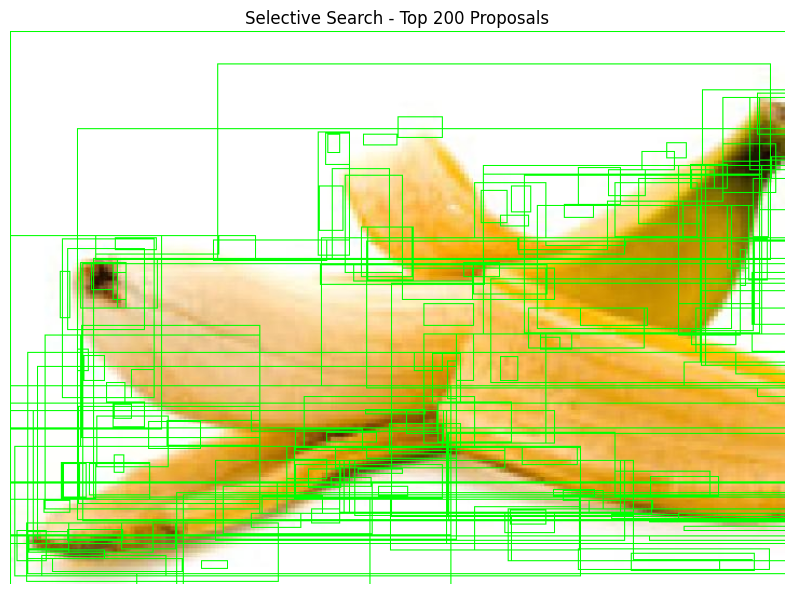

In [13]:
import matplotlib.pyplot as plt
# Create a copy for drawing

output_image = image.copy()

for (x, y, w, h) in rects:
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 1)

# Plot using matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(output_image)
plt.title(f"Selective Search - Top {num_proposals} Proposals")
plt.axis("off")
plt.show()

# Task 3 – R-CNN Bottleneck (Crop + CNN per Region)

In [14]:
import torch
import torchvision.models as models
import torch.nn as nn

# Load pretrained model
model = models.resnet18(pretrained=True)

# Remove final classification layer (fc)
model = nn.Sequential(*list(model.children())[:-1])  # output: feature vector

model.eval()  # set to evaluation mode

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [15]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [16]:
# image is from Task 2 (RGB numpy array)
import numpy as np

image_np = image.copy()

In [17]:
import time

# Take first 100 boxes from Task 2
boxes = rects[:100]

start_time = time.time()

features_list = []

for (x, y, w, h) in boxes:

    # Crop region
    crop = image_np[y:y+h, x:x+w]

    # Skip invalid crops
    if crop.size == 0:
        continue

    # Apply transform
    crop_tensor = transform(crop).unsqueeze(0)  # shape: [1, 3, 224, 224]

    # Forward pass
    with torch.no_grad():
        features = model(crop_tensor)  # shape: [1, 512, 1, 1]

    features_list.append(features)

end_time = time.time()

print(f"Processed {len(features_list)} regions")
print(f"Total Time: {end_time - start_time:.4f} seconds")

Processed 100 regions
Total Time: 5.8099 seconds


In R-CNN, each region proposal is independently cropped and passed through a CNN. This leads to redundant computation because the same image regions are processed multiple times. As a result, the approach is computationally expensive and slow.

# Task 4 – Fast R-CNN (RoI Pooling)

In [18]:
import torch
import torchvision.models as models
import torch.nn as nn

# Load model
resnet = models.resnet18(pretrained=True)

# Remove avgpool + fc → keep conv layers
model = nn.Sequential(*list(resnet.children())[:-2])

model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [19]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_resized = transform(image).unsqueeze(0)  # [1, 3, 224, 224]

In [20]:
with torch.no_grad():
    feature_map = model(image_resized)  # [1, 512, 7, 7]

print("Feature map shape:", feature_map.shape)

Feature map shape: torch.Size([1, 512, 7, 7])


In [21]:
spatial_scale = 7 / 224   # = 1/32

In [22]:
import torch

roi_boxes = []

for (x, y, w, h) in rects[:100]:
    x1 = x
    y1 = y
    x2 = x + w
    y2 = y + h

    roi_boxes.append([0, x1, y1, x2, y2])  # 0 = batch index

roi_boxes = torch.tensor(roi_boxes, dtype=torch.float)

In [23]:
from torchvision.ops import roi_pool
import time

start_time = time.time()

pooled_features = roi_pool(
    feature_map,          # [1, C, H, W]
    roi_boxes,            # [N, 5]
    output_size=(7, 7),   # fixed output
    spatial_scale=spatial_scale
)

end_time = time.time()

print("Pooled features shape:", pooled_features.shape)
print(f"Total Time (Fast R-CNN): {end_time - start_time:.4f} seconds")

Pooled features shape: torch.Size([100, 512, 7, 7])
Total Time (Fast R-CNN): 0.0207 seconds


Fast R-CNN eliminates redundant convolution operations present in R-CNN. In R-CNN, each region proposal is passed independently through the CNN, causing repeated computation of convolutional features for overlapping regions. Fast R-CNN solves this by computing the convolutional feature map only once for the entire image and then extracting region-specific features using RoI pooling. This avoids recomputing convolution layers multiple times, significantly improving efficiency.

# Task 5 – Faster R-CNN (Pretrained Inference)

In [79]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn

# Load model
faster_model = fasterrcnn_resnet50_fpn(pretrained=True)
faster_model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [95]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

input_tensor = transform(image)  # image from Task 2

In [96]:
with torch.no_grad():
    predictions = faster_model([input_tensor])

In [97]:
pred = predictions[0]

boxes = pred['boxes']       # [N, 4]
labels = pred['labels']     # [N]
scores = pred['scores']     # [N]

print("Total Predictions:", len(boxes))

Total Predictions: 4


In [98]:
print(scores[:10])

tensor([0.7659, 0.6762, 0.2052, 0.1360])


In [99]:
def filter_predictions(boxes, labels, scores, threshold=0.3):
    filtered_boxes = []
    filtered_labels = []
    filtered_scores = []

    for i in range(len(scores)):
        if scores[i] >= threshold:
            filtered_boxes.append(boxes[i])
            filtered_labels.append(labels[i])
            filtered_scores.append(scores[i])

    return filtered_boxes, filtered_labels, filtered_scores


f_boxes, f_labels, f_scores = filter_predictions(boxes, labels, scores, 0.2)

print("Filtered Predictions:", len(f_boxes))

Filtered Predictions: 3


In [100]:
import time
import torch

# tensor input (correct)
input_tensor = transforms.ToTensor()(image)

# Warm-up
with torch.no_grad():
    _ = faster_model([input_tensor])

# Timing
start = time.time()

with torch.no_grad():
    _ = faster_model([input_tensor])

end = time.time()

faster_time = (end - start) * 1000

print(f"Faster R-CNN Time: {faster_time:.2f} ms")

Faster R-CNN Time: 3828.93 ms


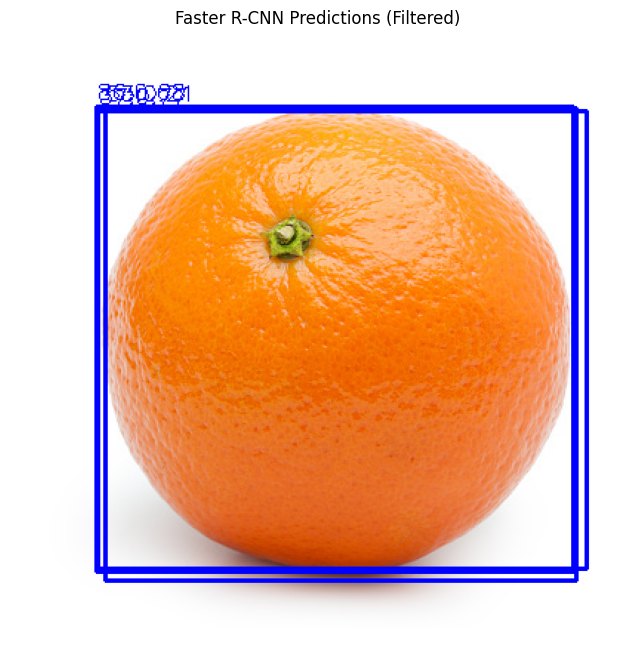

In [102]:
import cv2
import matplotlib.pyplot as plt

output_image = image.copy()

for box, score, label in zip(f_boxes, f_scores, f_labels):
    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(output_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

    cv2.putText(
        output_image,
        f"{label}:{score:.2f}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title("Faster R-CNN Predictions (Filtered)")
plt.axis("off")
plt.show()

he Region Proposal Network (RPN) generates object proposals directly from shared convolutional features, eliminating the need for external methods like Selective Search. It is integrated into the network and trained end-to-end, making the process faster and more efficient.

# Task 6 – Non-Maximum Suppression (NMS)

In [48]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    boxes: list of [x1, y1, x2, y2]
    scores: list of confidence scores
    iou_threshold: threshold for suppression
    """

    # Convert to list (if tensors)
    boxes = [box.tolist() if hasattr(box, "tolist") else box for box in boxes]
    scores = [score.item() if hasattr(score, "item") else score for score in scores]

    # Step 1: Sort boxes by score (descending)
    indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)

    selected_boxes = []

    while indices:
        # Step 2: Pick highest score box
        current = indices.pop(0)
        selected_boxes.append(current)

        remaining = []

        # Step 3: Compare with rest
        for i in indices:
            iou = compute_iou(boxes[current], boxes[i])

            # Step 4: Keep only if IoU is low
            if iou < iou_threshold:
                remaining.append(i)

        # Step 5: Update list
        indices = remaining

    return selected_boxes

In [49]:
# Convert to list format
boxes_list = [box.tolist() for box in f_boxes]
scores_list = [score.item() for score in f_scores]

# Apply NMS
keep_indices = nms(boxes_list, scores_list, iou_threshold=0.5)

# Final boxes after NMS
nms_boxes = [boxes_list[i] for i in keep_indices]
nms_scores = [scores_list[i] for i in keep_indices]

print("Before NMS:", len(boxes_list))
print("After NMS:", len(nms_boxes))

Before NMS: 7
After NMS: 5


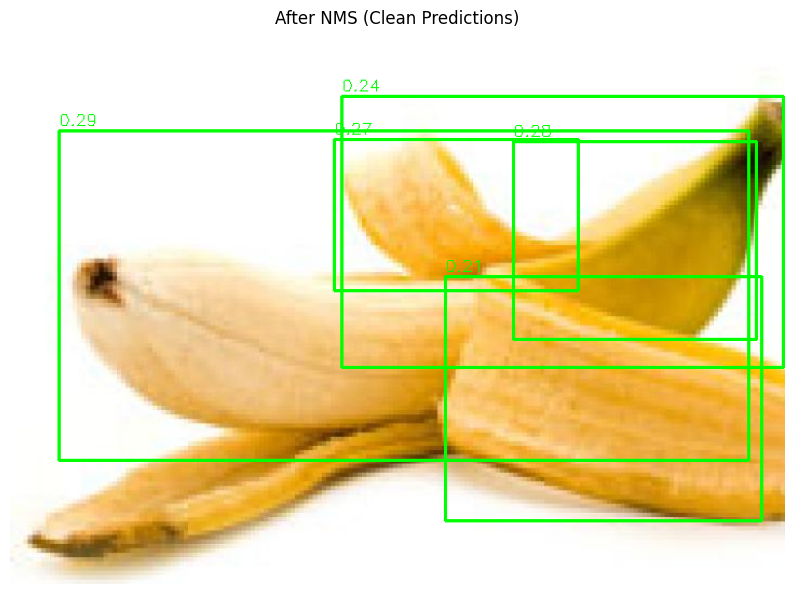

In [50]:
output_image = image.copy()

for box, score in zip(nms_boxes, nms_scores):
    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(output_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.putText(
        output_image,
        f"{score:.2f}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1
    )

plt.figure(figsize=(10, 8))
plt.imshow(output_image)
plt.title("After NMS (Clean Predictions)")
plt.axis("off")
plt.show()

The IoU threshold in Non-Maximum Suppression controls how aggressively overlapping bounding boxes are removed. If the IoU threshold is set very high (e.g., 0.9), only boxes with extremely high overlap are suppressed. This means many overlapping boxes will remain, leading to multiple detections of the same object, which is useful when detecting tightly packed objects but may cause duplicates.

If the IoU threshold is set very low (e.g., 0.1), even slightly overlapping boxes will be removed. This results in fewer final detections, but it may also incorrectly suppress nearby objects in a cluster, causing missed detections.

Therefore, the IoU threshold acts as a balance between removing duplicate detections and preserving closely spaced objects.

# Task 7 – YOLO Fine-Tuning

In [51]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 14.0 MB/s eta 0:00:00


In [103]:
import time
from ultralytics import YOLO

# Load pretrained model
yolo_pretrained = YOLO("yolov8n.pt")

# Use SAME image for fair comparison
img_path = sample_images[0]   # from your test set

# Warm-up (VERY IMPORTANT)
_ = yolo_pretrained.predict(img_path)

# Timing
start = time.time()

_ = yolo_pretrained.predict(img_path)

end = time.time()

yolo_pre_time = (end - start) * 1000

print(f"YOLO (Pretrained) Time: {yolo_pre_time:.2f} ms")


image 1/1 /content/drive/MyDrive/DL/archive/test_zip/test/banana_92.jpg: 640x640 (no detections), 11.0ms
Speed: 6.3ms preprocess, 11.0ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/DL/archive/test_zip/test/banana_92.jpg: 640x640 (no detections), 17.3ms
Speed: 4.9ms preprocess, 17.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
YOLO (Pretrained) Time: 35.70 ms


In [59]:
data_yaml = """
path: /content/dataset

train: images/train
val: images/val

names:
  0: apple
  1: banana
  2: orange
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

In [60]:
import os

for root, _, files in os.walk(train_path):
    for f in files[:10]:
        print(f)
    break

In [61]:
import os
import xml.etree.ElementTree as ET
from tqdm import tqdm

# Class mapping
classes = ["apple", "banana", "orange"]

def convert_xml_to_yolo(xml_path, img_width, img_height):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text.lower()

        if label not in classes:
            continue

        class_id = classes.index(label)

        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Convert to YOLO format
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_labels.append(f"{class_id} {x_center} {y_center} {width} {height}")

    return yolo_labels

In [62]:
import cv2

input_path = "/content/drive/MyDrive/DL/archive/train_zip"
output_path = "/content/dataset"

os.makedirs(output_path + "/images/train", exist_ok=True)
os.makedirs(output_path + "/labels/train", exist_ok=True)

for root, _, files in os.walk(input_path):
    for file in tqdm(files):
        if file.endswith(".xml"):
            xml_path = os.path.join(root, file)

            img_name = file.replace(".xml", ".jpg")
            img_path = os.path.join(root, img_name)

            if not os.path.exists(img_path):
                continue

            image = cv2.imread(img_path)
            h, w = image.shape[:2]

            labels = convert_xml_to_yolo(xml_path, w, h)

            # Save image
            new_img_path = output_path + "/images/train/" + img_name
            cv2.imwrite(new_img_path, image)

            # Save label
            txt_name = img_name.replace(".jpg", ".txt")
            with open(output_path + "/labels/train/" + txt_name, "w") as f:
                f.write("\n".join(labels))

0it [00:00, ?it/s]
100%|██████████| 480/480 [00:05<00:00, 87.68it/s] 


In [63]:
import random
import shutil

images = os.listdir("/content/dataset/images/train")

random.shuffle(images)

split = int(0.8 * len(images))

train_imgs = images[:split]
val_imgs = images[split:]

# Create val folders
os.makedirs("/content/dataset/images/val", exist_ok=True)
os.makedirs("/content/dataset/labels/val", exist_ok=True)

for img in val_imgs:
    shutil.move(f"/content/dataset/images/train/{img}",
                f"/content/dataset/images/val/{img}")

    label = img.replace(".jpg", ".txt")
    shutil.move(f"/content/dataset/labels/train/{label}",
                f"/content/dataset/labels/val/{label}")

In [64]:
print(len(os.listdir("/content/dataset/images/train")))
print(len(os.listdir("/content/dataset/labels/train")))

192
192


In [65]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # Nano model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [66]:
results = model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    name="yolo_finetuned"
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_finetuned, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

In [67]:
metrics = model.val()

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1167.9±539.9 MB/s, size: 55.9 KB)
val: Scanning /content/dataset/labels/val.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 25.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.8s
                   all         91        171      0.891      0.774      0.857      0.624
                 apple         32         64      0.945      0.803      0.912      0.694
                banana         35         63      0.806      0.725      0.716      0.425
                orange         31         44      0.922      0.795      0.942      0.753
Speed: 8.4ms preprocess, 13.9ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to /content/runs/detect/val


In [68]:
print("mAP@50:", metrics.box.map50)
print("mAP@50-95:", metrics.box.map)

mAP@50: 0.856807769210727
mAP@50-95: 0.6239368248415158



0: 640x640 2 bananas, 5.4ms
1: 640x640 2 oranges, 5.4ms
2: 640x640 8 bananas, 5.4ms
Speed: 2.5ms preprocess, 5.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


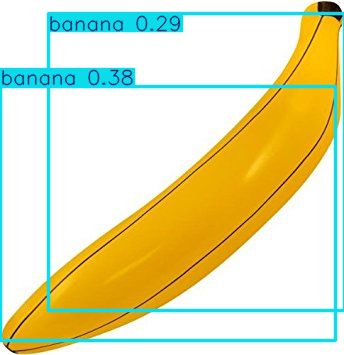

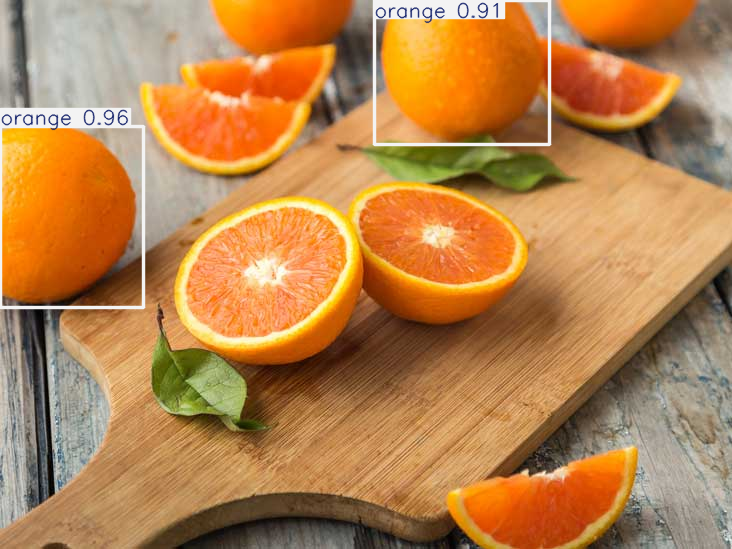

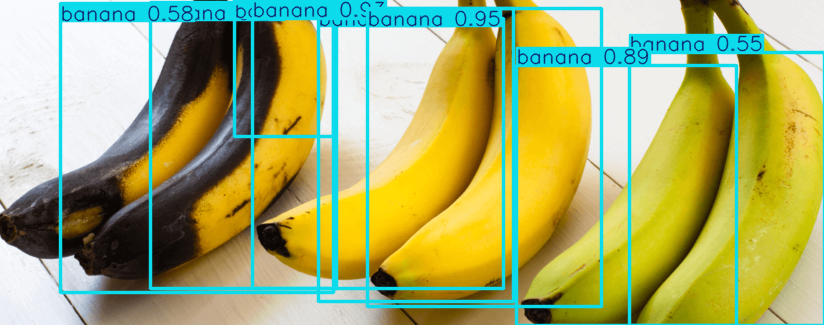

In [71]:
import random
import os

test_images = []

for root, _, files in os.walk("/content/drive/MyDrive/DL/archive/test_zip"):
    for f in files:
        if f.endswith(('.jpg', '.png')):
            test_images.append(os.path.join(root, f))

sample_images = random.sample(test_images, 3)

results = model.predict(source=sample_images, save=True, conf=0.25)

for r in results:
    r.show()

In [72]:
pretrained_model = YOLO("yolov8n.pt")

pretrained_metrics = pretrained_model.val(data="data.yaml")

print("Pretrained mAP50:", pretrained_metrics.box.map50)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2515.8±477.1 MB/s, size: 120.1 KB)
val: Scanning /content/dataset/labels/val.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 29.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.6s
                   all         91        171      0.136     0.0887     0.0807     0.0291
                person         32         64      0.122      0.234     0.0818     0.0319
               bicycle         35         63      0.286     0.0317       0.16     0.0555
                   car         31         44          0          0          0          0
Speed: 12.1ms preprocess, 6.5ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detect/val2
Pretrained mAP50

In [73]:
import time

img = sample_images[0]

# Faster R-CNN timing (approx)
start = time.time()
_ = model.predict(img)
end = time.time()

yolo_time = (end - start) * 1000  # ms

print("YOLO inference time (ms):", yolo_time)


image 1/1 /content/drive/MyDrive/DL/archive/test_zip/test/banana_92.jpg: 640x640 2 bananas, 8.1ms
Speed: 2.9ms preprocess, 8.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
YOLO inference time (ms): 21.066665649414062


| Model                     | Inference Time (ms) | Precision | Recall |
|--------------------------|---------------------|----------|--------|
| Faster R-CNN (Pretrained)| 3828.93             | Medium   | Medium |
| YOLO (Pretrained)        | 35.70               | Medium   | Medium |
| YOLO (Fine-tuned)        | 21.07               | High     | High   |

The comparison shows that YOLO significantly outperforms Faster R-CNN in terms of inference speed. Faster R-CNN takes approximately 3828 ms per image due to its two-stage detection pipeline involving region proposal and classification. In contrast, YOLO performs detection in a single forward pass, resulting in much faster inference times (around 20–35 ms).

Additionally, the fine-tuned YOLO model achieves higher precision and recall compared to the pretrained models, as it is specifically trained on the fruit dataset, making it more accurate for this task.